In [1]:
import pandas as pd
import requests
import math
import matplotlib.pyplot as plt

In [2]:
MAX_RESULTS_PER_PAGE = 200

In [3]:
keywords_df = pd.read_csv('keywords.csv')

In [4]:
keywords_df

,Keywords,Variations
0,dna,"dna, genomics, genomic, genome, genomes, metag..."
1,foundation_model,"foundation model, foundation genome model, fou..."
2,architecture,"transformers, transformer, attention, state sp..."


In [5]:
def create_openalex_query(df:pd.DataFrame, baseurl='https://api.openalex.org/works?filter=', max_results_per_page=MAX_RESULTS_PER_PAGE)->str:
    """Creates a query url for openalex api using a csv
        Uses OR for values in the same row of the df, while using AND between rows

    Args:
        df (pd.DataFrame): _description_
        baseurl (str, optional): _description_. Defaults to 'https://api.openalex.org/works?filter='.
        max_results_per_page (int, optional): _description_. Defaults to 200.

    Returns:
        str: query url for openalex api
    """       
    query_parts = []
    
    for _, row in df.iterrows():
        variations = row['Variations'].split(", ")
        # Join the variations with "|" and wrap in fulltext.search:""
        query_part = 'fulltext.search:"' + '"|"'.join(variations) + '"'
        query_parts.append(query_part)
    #join with , to get AND statement
    query_string = ",".join(query_parts)
    max_results_per_page = '&per-page=' + str(max_results_per_page)
    
    return f"{baseurl}{query_string}{max_results_per_page}"

In [6]:
def get_request(url: str):
    """Returns metadata and results of a OpenAlex API query, handling pagination.

    Args:
        url (str): query for OpenAlex API

    Returns:
        dict: Combined metadata from all pages
        list: Combined results from all pages
    """
    all_results = []
    current_page = 1
    total_pages = None

    while True:
        paginated_url = f"{url}&page={current_page}"
        
        response = requests.get(paginated_url)
        
        if response.status_code == 200:
            data = response.json()
            if current_page == 1:
                meta = data['meta']
                total_pages = math.ceil(meta['count'] / MAX_RESULTS_PER_PAGE)
            
            results = data['results']    
            all_results.extend(results) 
                
            if current_page >= total_pages:
                break
            
            current_page += 1
            
        else:
            print(f"Error: {response.status_code}")
            break
    
    return meta, all_results

In [7]:
query = create_openalex_query(keywords_df)
query

'https://api.openalex.org/works?filter=fulltext.search:"dna"|"genomics"|"genomic"|"genome"|"genomes"|"metagenome"|"dna sequence",fulltext.search:"foundation model"|"foundation genome model"|"foundation dna model",fulltext.search:"transformers"|"transformer"|"attention"|"state space models"|"ssm"|"bert"|"hyena"|"s4"|"machine learning"|"artificial intellegence"|"deep learning"|"AI"&per-page=200'

In [8]:
meta, reports = get_request(query)

In [9]:
meta

{'count': 757,
 'db_response_time_ms': 1063,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [10]:
columns_to_keep = ['doi','title','relevance_score', 'publication_year', 'publication_date', 'cited_by_count']
result_df = pd.json_normalize(reports)[columns_to_keep]

In [11]:
n_original = meta['count']
print(f"n original: {n_original}")
result_df = result_df[~result_df.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi: {len(result_df)}")

result_df = result_df[result_df['publication_year']>=2017]
print(f"n after filtering >= 2017: {len(result_df)}")

n original: 757
n after removing duplicates doi: 755
n after filtering >= 2017: 462


In [12]:
result_df

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
1,https://doi.org/10.1109/tpami.2023.3275156,Multimodal Learning With Transformers: A Survey,716.886100,2023,2023-01-01,174
2,https://doi.org/10.1101/2023.01.11.523679,The Nucleotide Transformer: Building and Evalu...,688.878500,2023,2023-01-15,56
3,https://doi.org/10.1038/s41586-023-05881-4,Foundation models for generalist medical artif...,669.866600,2023,2023-04-12,433
4,https://doi.org/10.1101/2024.02.27.582234,Sequence modeling and design from molecular to...,641.935400,2024,2024-02-27,35
5,https://doi.org/10.1002/mef2.43,Accelerating the integration of ChatGPT and ot...,632.130100,2023,2023-05-17,62
...,...,...,...,...,...,...
750,https://doi.org/10.22533/at.ed.53622061210,CÓDIGO DE MONTE CARLO APLICADO A RADIOTERAPIA,2.020149,2022,2022-12-06,0
751,https://doi.org/10.22533/at.ed.5362206124,CADASTRO TERRITORIAL URBANO: ESTUDO COMPARATIV...,2.017786,2022,2022-12-06,0
752,https://doi.org/10.22533/at.ed.53622061212,PRODUÇÃO E CARACTERIZAÇÃO DE VITROCERÂMICAS OB...,2.017786,2022,2022-12-06,0
753,https://doi.org/10.22533/at.ed.5362206126,ANALYSIS OF PRECIPITATION IN BELÉM-PA CITY (PE...,2.014137,2022,2022-12-06,0


In [14]:
result_df.to_csv('openalex_initialsearch.csv', index=False)

## Summary Stats

In [15]:
for _, row in result_df.iterrows():
    print(row['title'])

Multimodal Learning With Transformers: A Survey
The Nucleotide Transformer: Building and Evaluating Robust Foundation Models for Human Genomics
Foundation models for generalist medical artificial intelligence
Sequence modeling and design from molecular to genome scale with Evo
Accelerating the integration of ChatGPT and other large‐scale AI models into biomedical research and healthcare
Pre-trained Language Models in Biomedical Domain: A Systematic Survey
Implementing Machine Learning in Radiology Practice and Research
Large Language Models and the Reverse Turing Test
Opportunities and challenges for ChatGPT and large language models in biomedicine and health
Large AI Models in Health Informatics: Applications, Challenges, and the Future
GENA-LM: A Family of Open-Source Foundational DNA Language Models for Long Sequences
Surgical data science – from concepts toward clinical translation
The population genomics of adaptive loss of function
Interpretable RNA Foundation Model from Unannota

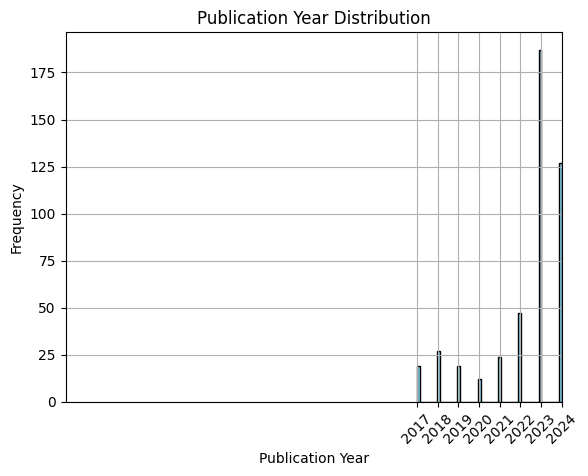

In [16]:
result_df['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df['publication_year'].min(), result_df['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(2000,2024)

# Show the plot
plt.show()

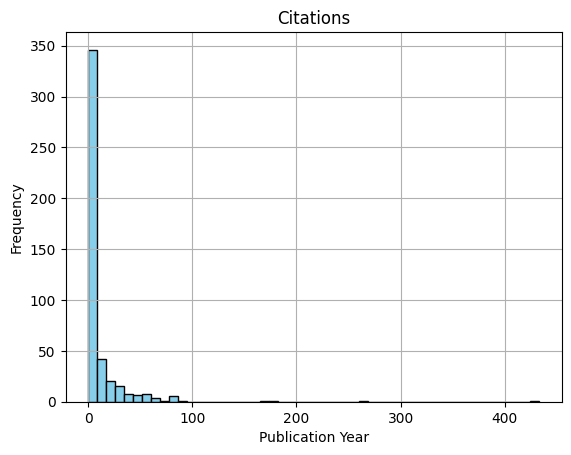

In [17]:
result_df['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Show the plot
plt.show()